# Data preparation - Feature Engineering
Created by Guillermo Arredondo Renero

Creation date: May 5, 2026  
Last updated: May 5, 2026

**Main objective**: Realize feature engineering over interim data (cleaned data) to empower models in next stage. **Only for continous prediction - Amount of previous payment in June**

In [153]:
# ---------------------------- Libraries
## Directories
import os
## Data manipulation
import pandas as pd
import numpy as np

## Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable

# Extras
import warnings
warnings.filterwarnings('ignore')

# Transformation
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

In [154]:
# ---------------------------- Directories
# Get main directory
CURRENT_DIR = os.getcwd()
MAIN_DIR = os.path.dirname(CURRENT_DIR)
INTERIM_DIR = os.path.join(MAIN_DIR, 'data', 'interim')
PROCESSED_DIR = os.path.join(MAIN_DIR, 'data', 'processed')
os.makedirs(PROCESSED_DIR, exist_ok=True)

## Data loading

In [155]:
df = pd.read_csv(os.path.join(INTERIM_DIR, 'credit_dataset_cleaned.csv'))

Aquí asumimos que BILL_AMT4 es un valor con el que sí se puede contar antes de la predicción de pago; sin embargo, depende de información con la que no se cuenta. No estoy muy seguro sobre como considerar a la variable PAY_4 pero dado que su correlación es prácticamente nula no me preocupa tirarla. En caso de observar overfitting podría regresar y eliminar BILL_AMT4 y probar nuevamente.

In [156]:
# Drop variables after prediction time 1 = September, 2=August, 3=July and default payment as next month probably refers to october
out_of_time_cols = [col for col in df.columns if col.endswith(('1', '2', '3')) or col in ["default_payment_next_month", "PAY_4"]]
print(f"Dropping {len(out_of_time_cols)} columns related to out-of-time features.")
print(out_of_time_cols)
df.drop(columns=out_of_time_cols, inplace=True)
original_features = df.columns
df.head()

Dropping 11 columns related to out-of-time features.
['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'default_payment_next_month']


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_5,PAY_6,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,-1,-1,0,0,0,0,0,0
1,120000,2,2,2,26,1,3,3272,3455,3261,1000,0,2000
2,90000,2,2,2,34,1,1,14331,14948,15549,1000,1000,5000
3,50000,2,2,1,37,1,1,28314,28959,29547,1100,1069,1000
4,50000,1,2,1,57,1,1,20940,19146,19131,9000,689,679


## Transformations

### Categorical variables

Dado que no son muchas categorías para las variables categóricas no tenemos problema en usar One-Hot Encoding.  
Nótese que crearemos las variables dummy y eliminaremos la categórica ordinal, sin embargo, pudieramos usar la variable en forma ordinal para árboles de decisión de forma óptima. Dado que planeamos usar más que modelos de árboles y por simplicidad de código, usaremos la códificos OHE para todos los algoritmos por igual.

In [157]:
# Get Female dummy variable
df['Female'] = df['SEX'] - 1

# Replace marriage and education with mapping
education_map = {1: 'Graduate', 2: 'University', 3: 'High School', 4: 'Others'}
marriage_map = {1: 'Married', 2: 'Single', 3: 'Others'}
df['EDUCATION'] = df['EDUCATION'].map(education_map)
df['MARRIAGE'] = df['MARRIAGE'].map(marriage_map)

# Create One Hot Encodings for MARRIAGE and EDUCATION
df = pd.concat(
    [
        df,
        pd.get_dummies(df.MARRIAGE, prefix='MARRIAGE').astype(int),
        pd.get_dummies(df.EDUCATION, prefix='EDUCATION').astype(int)
    ],
    axis=1
)

df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_5,PAY_6,BILL_AMT4,BILL_AMT5,BILL_AMT6,...,PAY_AMT5,PAY_AMT6,Female,MARRIAGE_Married,MARRIAGE_Others,MARRIAGE_Single,EDUCATION_Graduate,EDUCATION_High School,EDUCATION_Others,EDUCATION_University
0,20000,2,University,Married,24,-1,-1,0,0,0,...,0,0,1,1,0,0,0,0,0,1
1,120000,2,University,Single,26,1,3,3272,3455,3261,...,0,2000,1,0,0,1,0,0,0,1
2,90000,2,University,Single,34,1,1,14331,14948,15549,...,1000,5000,1,0,0,1,0,0,0,1
3,50000,2,University,Married,37,1,1,28314,28959,29547,...,1069,1000,1,1,0,0,0,0,0,1
4,50000,1,University,Married,57,1,1,20940,19146,19131,...,689,679,0,1,0,0,0,0,0,1


In [158]:
# Drop original MARRIAGE and EDUCATION columns
df.drop(['MARRIAGE', 'EDUCATION'], axis=1, inplace=True)

### New variables

In [159]:
bill_cols = ['BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_amt_cols = ['PAY_AMT5', 'PAY_AMT6']
pay_cols = ['PAY_5', 'PAY_6']

# Credit utilization per bill statement - UPGRADE over only last one
    # What happens if negative? -> i guess its something relevant but idk if should be clipped to zero?
for i, col in enumerate(bill_cols, start=4):
    df[f'util_{i}'] = df[f'BILL_AMT{i}'] / (df['LIMIT_BAL'] + 1)  # Avoid division by zero

# Payment ratio (how much of the bill was paid)
    # Problem bill can be negative -> no positive bill = fully paid (refund or overpaid?)
for i, col in enumerate(pay_amt_cols, start=5):
    df[f'pay_ratio_{i}'] = np.where(
        df[f'BILL_AMT{i}'] > 0,
        df[f'PAY_AMT{i}'] / (df[f'BILL_AMT{i}'] + 1),
        1  
    )

# Remaining balance after payment
for i, col in enumerate(pay_amt_cols, start=4):
    df[f'remaining_bal_{i}'] = df[f'BILL_AMT{i}'] - df[f'PAY_AMT{i}']
    
# Calculate average monthly bill and payment
df['avg_monthly_bill'] = df[bill_cols].mean(axis=1)
df['avg_monthly_payment'] = df[pay_amt_cols].mean(axis=1)

# Create a feature: maximum payment delay across months
df['max_payment_delay'] = df[pay_cols].max(axis=1)
df['has_any_delay'] = (df['max_payment_delay'] > 0).astype(int)

# Number of delayed months
df['n_months_delayed']= (df[pay_cols] > 0).sum(axis=1)

# Bill trend
df['bill_trend'] = df[bill_cols[0]] - df[bill_cols[-1]]

# Payment Consistency (Volatility) an coefficient of variation could be interesting as well
df['payment_volatility'] = df[pay_amt_cols].std(axis=1)
df['payment_cv'] = df['payment_volatility'] / (df['avg_monthly_payment'] + 1)  # Avoid division by zero
df['recent_payment_below_avg'] = (df[pay_amt_cols[0]] < df['avg_monthly_payment']).astype(int)

# Total bill and payment amounts -> net debt
df['total_bill'] = df[bill_cols].sum(axis=1)
df['total_payment'] = df[pay_amt_cols].sum(axis=1)
df['net_debt'] = df['total_bill'] - df['total_payment']

# Overall utilization
df['overall_util'] = df['total_bill'] / (df['LIMIT_BAL'] + 1)  # Avoid division by zero

# Zero count -> bills = no use: pay = no payment
df['bill_zero_count'] = (df[bill_cols] == 0).sum(axis=1)
df['pay_zero_count'] = (df[pay_amt_cols] == 0).sum(axis=1)

# # Age groups as OHE
# df['age_group'] = pd.cut(df['AGE'], bins=[20, 30, 40, 50, 80],
#                           labels=['20s','30s','40s','50+'])

# df.drop('AGE', axis=1, inplace=True)


# Interactions between age and education and marriage -> pending

In [160]:
# Display new features created
new_features = [col for col in df.columns if col not in original_features]

print("="*80)
print("FEATURE ENGINEERING SUMMARY")
print("="*80)
print(f"\nOriginal features: {len(pd.read_csv(os.path.join(INTERIM_DIR, 'credit_dataset_cleaned.csv')).columns)}")
print(f"New features created: {len(new_features)}")
print(f"Total features: {len(df.columns)}")
print(f"\n📊 NEW FEATURES ({len(new_features)} total):")
print("-" * 80)

print("\n" + "="*80)
print("Feature Statistics:")
print("="*80)
print(f"\nFeature with highest correlation to target (excluding original PAY_ features):")
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_with_target = df[numeric_cols].corr()['PAY_AMT4'].sort_values(ascending=False)
# Show top 10 new features by correlation
new_feature_corrs = corr_with_target[[f for f in corr_with_target.index if f in new_features and f != 'PAY_AMT4']]
print(new_feature_corrs.head(10))
print("\n" + "="*80)
df[new_features].describe()

FEATURE ENGINEERING SUMMARY

Original features: 24
New features created: 30
Total features: 41

📊 NEW FEATURES (30 total):
--------------------------------------------------------------------------------

Feature Statistics:

Feature with highest correlation to target (excluding original PAY_ features):
remaining_bal_5        0.256141
total_bill             0.227538
avg_monthly_bill       0.227538
net_debt               0.204063
total_payment          0.202862
avg_monthly_payment    0.202862
payment_volatility     0.112020
util_5                 0.093498
util_6                 0.064912
EDUCATION_Graduate     0.046228
Name: PAY_AMT4, dtype: float64



,Female,MARRIAGE_Married,MARRIAGE_Others,MARRIAGE_Single,EDUCATION_Graduate,EDUCATION_High School,EDUCATION_Others,EDUCATION_University,util_4,util_5,...,bill_trend,payment_volatility,payment_cv,recent_payment_below_avg,total_bill,total_payment,net_debt,overall_util,bill_zero_count,pay_zero_count
count,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,...,29601.000000,29601.000000,29601.000000,29601.000000,2.960100e+04,29601.000000,2.960100e+04,29601.000000,29601.000000,29601.000000
mean,0.603189,0.455289,0.010743,0.533968,0.357454,0.164623,0.004155,0.473768,0.358934,0.333090,...,4264.104388,3830.193359,0.520657,0.375055,1.222165e+05,9976.359109,1.122402e+05,1.011173,0.354887,0.460897
std,0.489244,0.498005,0.103091,0.498853,0.479258,0.370846,0.064328,0.499320,0.368237,0.350213,...,27714.922599,14690.048367,0.562463,0.484145,1.800484e+05,25050.797575,1.758574e+05,1.024297,0.856393,0.723892
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.374431,-0.876730,...,-472227.000000,0.000000,0.000000,0.000000,-3.383800e+05,0.000000,-6.836730e+05,-2.249888,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.014263,0.011194,...,-1549.000000,8.485281,0.005375,0.000000,9.024000e+03,1150.000000,2.916000e+03,0.057538,0.000000,0.000000
50%,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.241164,0.212308,...,0.000000,424.264069,0.263725,0.000000,5.544600e+04,3500.000000,4.811800e+04,0.679326,0.000000,0.000000
75%,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.667763,0.602540,...,4979.000000,1816.557321,1.149309,1.000000,1.515020e+05,9000.000000,1.431670e+05,1.820487,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.146593,4.935253,...,454653.000000,373681.892227,1.414205,1.000000,2.780421e+06,540541.000000,2.680165e+06,13.957952,3.000000,2.000000


### Data partition

In [161]:
CONT_PRED_DIR = os.path.join(PROCESSED_DIR, "continuous_prediction")
os.makedirs(CONT_PRED_DIR, exist_ok=True)

In [162]:
# Create directories for train, test and val sets
for split in ['train', 'test', 'val']:
    os.makedirs(os.path.join(CONT_PRED_DIR, split), exist_ok=True)

In [163]:
# Split data into features and target
X = df.drop(columns=['PAY_AMT4'])
y = df['PAY_AMT4']

# Split into train (65%), test (20%), and validation (15%) sets
# Split off test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y , test_size = 0.2, random_state=65)

# Second split: split 80 into 65-and 15 (15% = 0.15/0.8 = 0.1875 of the original data)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1875, random_state=65
)

print("="*80)
print("DATA SPLIT SUMMARY")
print("="*80)
print(f"\nTraining Set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation Set: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test Set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTotal Samples: {len(X)}")
print(f"Total Features: {X.shape[1]}")
print("="*80)

DATA SPLIT SUMMARY

Training Set: 19240 samples (65.0%)
Validation Set: 4440 samples (15.0%)
Test Set: 5921 samples (20.0%)

Total Samples: 29601
Total Features: 40


### Scaling & Transformations

In [164]:
# Identify features to scale
# Binary/categorical features should NOT be scaled
binary_features = [col for col in X.columns if df[col].nunique() == 2]
categorical_features = [col for col in X.columns if col.startswith('MARRIAGE') or col.startswith('EDUCATION') or col.startswith('age_group') or col == 'max_payment_delay'] + \
    [f'PAY_{i}' for i in range(1, 7)] + [col for col in X.columns if X[col].nunique() <= 8]
non_scaled_features = binary_features + categorical_features

# Features to scale: all numeric features except categorical/binary
features_to_scale = [col for col in X.select_dtypes(include=[np.number]).columns 
                     if col not in non_scaled_features]

print(f"Features to scale: {len(features_to_scale)}")
print(f"Binary features (not scaled): {len(binary_features)}")
print(f"Categorical features (not scaled): {len(categorical_features)}")
print(f"\nSample of features to scale: {features_to_scale}")

Features to scale: 23
Binary features (not scaled): 11
Categorical features (not scaled): 28

Sample of features to scale: ['LIMIT_BAL', 'AGE', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT5', 'PAY_AMT6', 'util_4', 'util_5', 'util_6', 'pay_ratio_5', 'pay_ratio_6', 'remaining_bal_4', 'remaining_bal_5', 'avg_monthly_bill', 'avg_monthly_payment', 'bill_trend', 'payment_volatility', 'payment_cv', 'total_bill', 'total_payment', 'net_debt', 'overall_util']


In [165]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,19240.0,168055.492723,130398.680662,10000.000000,50000.000000,140000.000000,240000.000000,1.000000e+06
SEX,19240.0,1.603378,0.489209,1.000000,1.000000,2.000000,2.000000,2.000000e+00
AGE,19240.0,35.476871,9.268841,21.000000,28.000000,34.000000,41.000000,7.900000e+01
PAY_5,19240.0,0.539241,1.313414,-1.000000,-1.000000,1.000000,1.000000,9.000000e+00
PAY_6,19240.0,0.507744,1.327398,-1.000000,-1.000000,1.000000,1.000000,9.000000e+00
BILL_AMT4,19240.0,43080.375364,64449.204784,-170000.000000,2303.750000,18940.500000,54025.750000,8.915860e+05
BILL_AMT5,19240.0,40122.052703,60677.749577,-81334.000000,1712.750000,17896.500000,50066.000000,9.271710e+05
BILL_AMT6,19240.0,38730.219335,59429.985116,-73895.000000,1240.000000,16922.000000,48976.500000,9.616640e+05
PAY_AMT5,19240.0,4793.764969,15402.461813,0.000000,245.500000,1500.000000,4095.000000,4.265290e+05
PAY_AMT6,19240.0,5236.592568,17775.434958,0.000000,133.000000,1500.000000,4006.000000,5.271430e+05


In [166]:
# Apply RobustScaler to features (better than StandardScaler for skewed distributions with outliers)
preprocessor = ColumnTransformer(transformers=[
    ('robust_scaler', RobustScaler(), features_to_scale)
], remainder='passthrough')

# Fit and transform the training data, then transform validation and test sets
X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)

# Get the correct feature names in the transformed order
feature_names_out = preprocessor.get_feature_names_out()
# Remove the prefixes ('robust_scaler__' or 'remainder__') to get original names
columns_after_scaling = [name.split('__')[1] for name in feature_names_out]

# Create DataFrames with correct column order
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=columns_after_scaling, index=X_train.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=columns_after_scaling, index=X_val.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=columns_after_scaling, index=X_test.index)

assert not X_train_scaled_df[features_to_scale].astype('float64').isnull().any().any(), 'Transform went wrong'
assert not X_val_scaled_df[features_to_scale].astype('float64').isnull().any().any(), 'Transform went wrong'
assert not X_test_scaled_df[features_to_scale].astype('float64').isnull().any().any(), 'Transform went wrong'

# Verify scaling by comparing before and after
print("\n" + "="*80)
print("SCALING VERIFICATION - RobustScaler (IQR-based)")
print("="*80)

print("\n📊 TRAINING SET - Before Scaling:")
print(X_train.shape)
print(X_train[features_to_scale].describe().loc[['count', 'mean', 'std', 'min', 'max']].round(3))

print("\n📊 TRAINING SET - After Scaling:")
print(X_train_scaled_df.shape)
print(X_train_scaled_df[features_to_scale].astype('float64').describe().loc[['count', 'mean', 'std', 'min', 'max']].round(3))

print("\n" + "-"*80)
print("\n📊 VALIDATION SET - Before Scaling:")
print(X_val.shape)
print(X_val[features_to_scale].describe().loc[['count', 'mean', 'std', 'min', 'max']].round(3))

print("\n📊 VALIDATION SET - After Scaling:")
print(X_val_scaled_df.shape)
print(X_val_scaled_df[features_to_scale].astype('float64').describe().loc[['count', 'mean', 'std', 'min', 'max']].round(3))

print("\n" + "-"*80)
print("\n📊 TEST SET - Before Scaling:")
print(X_test.shape)
print(X_test[features_to_scale].describe().loc[['count', 'mean', 'std', 'min', 'max']].round(3))

print("\n📊 TEST SET - After Scaling:")
print(X_test_scaled_df.shape)
print(X_test_scaled_df[features_to_scale].astype('float64').describe().loc[['count', 'mean', 'std', 'min', 'max']].round(3))

print("\n" + "="*80)


SCALING VERIFICATION - RobustScaler (IQR-based)

📊 TRAINING SET - Before Scaling:
(19240, 40)
         LIMIT_BAL        AGE   BILL_AMT4   BILL_AMT5   BILL_AMT6    PAY_AMT5  \
count    19240.000  19240.000   19240.000   19240.000   19240.000   19240.000   
mean    168055.493     35.477   43080.375   40122.053   38730.219    4793.765   
std     130398.681      9.269   64449.205   60677.750   59429.985   15402.462   
min      10000.000     21.000 -170000.000  -81334.000  -73895.000       0.000   
max    1000000.000     79.000  891586.000  927171.000  961664.000  426529.000   

         PAY_AMT6     util_4     util_5     util_6  ...  remaining_bal_5  \
count   19240.000  19240.000  19240.000  19240.000  ...        19240.000   
mean     5236.593      0.356      0.331      0.317  ...        35328.288   
std     17775.435      0.366      0.350      0.344  ...        60464.361   
min         0.000     -0.876     -0.765     -0.580  ...      -414380.000   
max    527143.000      4.645      4.93

### Save processed datasets

In [167]:
# Create directories for train, test and val sets
for split in ['train', 'test', 'val']:
    os.makedirs(os.path.join(CONT_PRED_DIR, split), exist_ok=True)

# Save non scaled data
# Combine X and y for each set
train_data = pd.concat([X_train, y_train], axis=1)
val_data = pd.concat([X_val, y_val], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

# Save datasets
train_data.to_csv(os.path.join(CONT_PRED_DIR, 'train', 'train_data.csv'), index=False)
val_data.to_csv(os.path.join(CONT_PRED_DIR, 'val', 'val_data.csv'), index=False)
test_data.to_csv(os.path.join(CONT_PRED_DIR, 'test', 'test_data.csv'), index=False)

# Save scaled data
# Combine X and y for each set
train_data_scaled = pd.concat([X_train_scaled_df, y_train], axis=1)
val_data_scaled = pd.concat([X_val_scaled_df, y_val], axis=1)
test_data_scaled = pd.concat([X_test_scaled_df, y_test], axis=1)

# Save datasets
train_data_scaled.to_csv(os.path.join(CONT_PRED_DIR, 'train', 'train_data_scaled.csv'), index=False)
val_data_scaled.to_csv(os.path.join(CONT_PRED_DIR, 'val', 'val_data_scaled.csv'), index=False)
test_data_scaled.to_csv(os.path.join(CONT_PRED_DIR, 'test', 'test_data_scaled.csv'), index=False)

# Also save feature names for reference
feature_names = pd.DataFrame({
    'feature_name': X.columns.tolist(),
    'feature_type': [
        'binary' if col in binary_features else 
        'categorical' if col in categorical_features else
        'numeric'
        for col in X.columns
    ]
})
feature_names.to_csv(os.path.join(CONT_PRED_DIR, 'feature_names.csv'), index=False)

print("✅ Datasets saved successfully!")
print(f"\nFiles saved in: {CONT_PRED_DIR}")
print(f"  • train_data.csv ({len(train_data)} rows, {len(train_data.columns)} columns)")
print(f"      • train_data_scaled.csv ({len(train_data_scaled)} rows, {len(train_data_scaled.columns)} columns)")
print(f"  • val_data.csv ({len(val_data)} rows, {len(val_data.columns)} columns)")
print(f"      • val_data_scaled.csv ({len(val_data_scaled)} rows, {len(val_data_scaled.columns)} columns)")
print(f"  • test_data.csv ({len(test_data)} rows, {len(test_data.columns)} columns)")
print(f"      • test_data_scaled.csv ({len(test_data_scaled)} rows, {len(test_data_scaled.columns)} columns)")
print(f"  • feature_names.csv (Feature metadata)")

# # Save scaler parameters for future predictions
# import pickle
# with open(os.path.join(BINARY_DIR, 'scaler.pkl'), 'wb') as f:
#     pickle.dump(scaler, f)
# print(f"  • scaler.pkl (RobustScaler for applying same transformation to new data)")

# print("\n" + "="*80)

✅ Datasets saved successfully!

Files saved in: c:\Users\Memit\OneDrive - INSTITUTO TECNOLOGICO AUTONOMO DE MEXICO\Documentos\AplicacionesTrabajo\Bluetab\default_credit_prediction\data\processed\continuous_prediction
  • train_data.csv (19240 rows, 41 columns)
      • train_data_scaled.csv (19240 rows, 41 columns)
  • val_data.csv (4440 rows, 41 columns)
      • val_data_scaled.csv (4440 rows, 41 columns)
  • test_data.csv (5921 rows, 41 columns)
      • test_data_scaled.csv (5921 rows, 41 columns)
  • feature_names.csv (Feature metadata)


## New features analysis

In [168]:
# Feature Engineering Final Analysis
print("="*80)
print("FEATURE ENGINEERING - FINAL ANALYSIS")
print("="*80)

# Correlation analysis for new features
numeric_df = train_data.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['PAY_AMT4'].drop('PAY_AMT4').sort_values(ascending=False)

print("\n📊 TOP 15 MOST CORRELATED FEATURES WITH DEFAULT:")
print("-" * 80)
for i, (feat, corr) in enumerate(correlations.head(15).items(), 1):
    print(f"{i:2d}. {feat:40s} → {corr:+.4f}")

print("\n\n DIMENSIONALITY SUMMARY:")
print("-" * 80)
print(f"Original dataset features: {len(original_features) - 1}")
print(f"One-hot encoded categorical features: {len([c for c in X.columns if c.startswith('MARRIAGE_') or c.startswith('EDUCATION_')])}")
print(f"Engineered new features: {len(new_features)}")
print(f"Total features in model: {X.shape[1]}")
print(f"\nFeature composition:")
print(f"  • Binary indicators: {len(binary_features)}")
print(f"  • Categorical dummies: {len(categorical_features)}")
print(f"  • Scaled numeric: {len(features_to_scale)}")
print("="*80)

FEATURE ENGINEERING - FINAL ANALYSIS

📊 TOP 15 MOST CORRELATED FEATURES WITH DEFAULT:
--------------------------------------------------------------------------------
 1. BILL_AMT5                                → +0.2859
 2. remaining_bal_5                          → +0.2544
 3. BILL_AMT6                                → +0.2387
 4. avg_monthly_bill                         → +0.2143
 5. total_bill                               → +0.2143
 6. LIMIT_BAL                                → +0.1940
 7. net_debt                                 → +0.1927
 8. total_payment                            → +0.1859
 9. avg_monthly_payment                      → +0.1859
10. PAY_AMT6                                 → +0.1537
11. PAY_AMT5                                 → +0.1277
12. BILL_AMT4                                → +0.1091
13. payment_volatility                       → +0.1056
14. util_5                                   → +0.0938
15. util_6                                   → +0.0624


 DIMEN

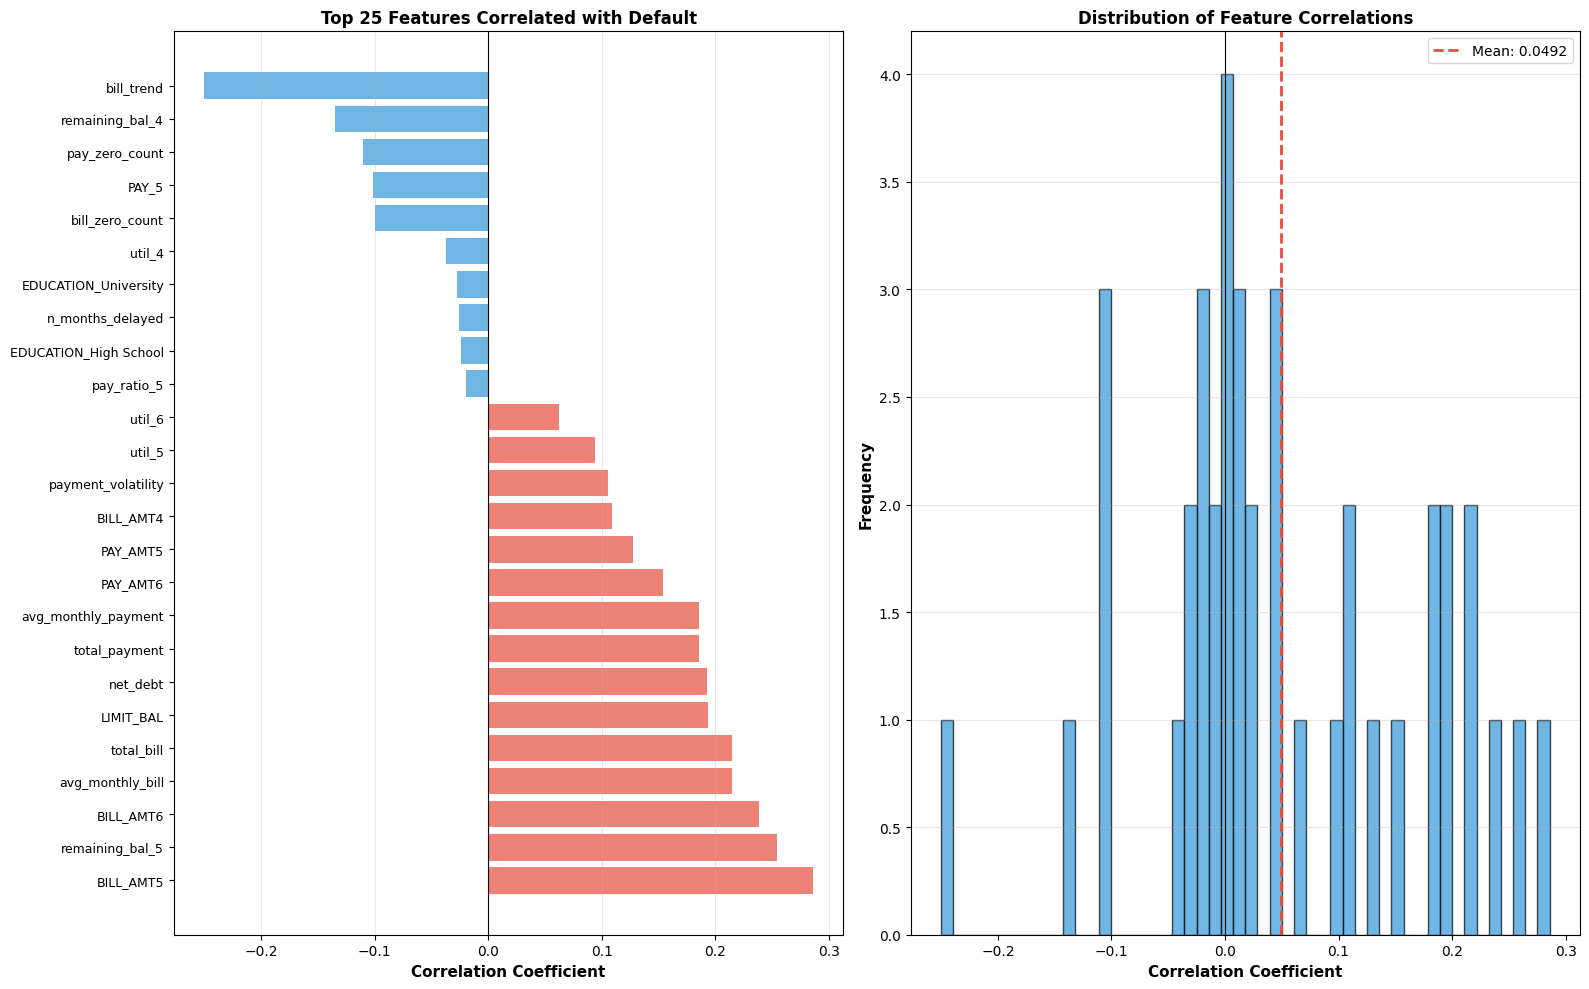


📊 CORRELATION STATISTICS:
  Mean correlation: +0.0492
  Median correlation: +0.0181
  Std dev: 0.1180
  Features with |r| > 0.15: 11
  Features with |r| > 0.10: 18
  Features with |r| > 0.05: 20


In [169]:
# Visualize feature correlations with target
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Top positive and negative correlations
top_positive = correlations.head(15)
top_negative = correlations.tail(10)
top_combined = pd.concat([top_positive, top_negative])

# Color bars
colors = ['#e74c3c' if x > 0 else '#3498db' for x in top_combined.values]

axes[0].barh(range(len(top_combined)), top_combined.values, color=colors, alpha=0.7)
axes[0].set_yticks(range(len(top_combined)))
axes[0].set_yticklabels(top_combined.index, fontsize=9)
axes[0].set_xlabel('Correlation Coefficient', fontsize=11, fontweight='bold')
axes[0].set_title('Top 25 Features Correlated with Default', fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[0].grid(axis='x', alpha=0.3)

# Histogram of all correlations
axes[1].hist(correlations.values, bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[1].axvline(x=correlations.mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean: {correlations.mean():.4f}')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_xlabel('Correlation Coefficient', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1].set_title('Distribution of Feature Correlations', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics on correlations
print("\n📊 CORRELATION STATISTICS:")
print(f"  Mean correlation: {correlations.mean():+.4f}")
print(f"  Median correlation: {correlations.median():+.4f}")
print(f"  Std dev: {correlations.std():.4f}")
print(f"  Features with |r| > 0.15: {len(correlations[abs(correlations) > 0.15])}")
print(f"  Features with |r| > 0.10: {len(correlations[abs(correlations) > 0.10])}")
print(f"  Features with |r| > 0.05: {len(correlations[abs(correlations) > 0.05])}")